In [87]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing (3).csv


We imported the dataset into our system


In [88]:
import pandas as pd

df = pd.read_csv('housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


Understanding the data

In [89]:
df.head(10)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386
5,80175.75416,4.988408,6.104512,4.04,26748.42842,1.068138e+06,"06039 Jennifer Islands Apt. 443\nTracyport, KS..."
6,64698.46343,6.025336,8.147760,3.41,60828.24909,1.502056e+06,"4759 Daniel Shoals Suite 442\nNguyenburgh, CO ..."
7,78394.33928,6.989780,6.620478,2.42,36516.35897,1.573937e+06,"972 Joyce Viaduct\nLake William, TN 17778-6483"
8,59927.66081,5.362126,6.393121,2.30,29387.39600,7.988695e+05,USS Gilbert\nFPO AA 20957
9,81885.92718,4.423672,8.167688,6.10,40149.96575,1.545155e+06,Unit 9446 Box 0958\nDPO AE 97025


In [90]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.94414,7.830362,6.137356,3.46,22837.36103,1060193.786,USNS Williams\nFPO AP 30153-7653
4996,78491.27543,6.999135,6.576763,4.02,25616.11549,1482617.729,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.68689,7.250591,4.805081,2.13,33266.14549,1030729.583,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.33124,5.534388,7.130144,5.44,42625.62016,1198656.872,USS Wallace\nFPO AE 73316
4999,65510.58180,5.992305,6.792336,4.07,46501.28380,1298950.480,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [92]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

We cleaned the data, converted it into numerical form, and separated input
features and target variable.

In [93]:
df = df.drop('Address', axis=1, errors='ignore')

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Price', axis=1)
y = df['Price']

**Before vs After Outlier** **Removal**

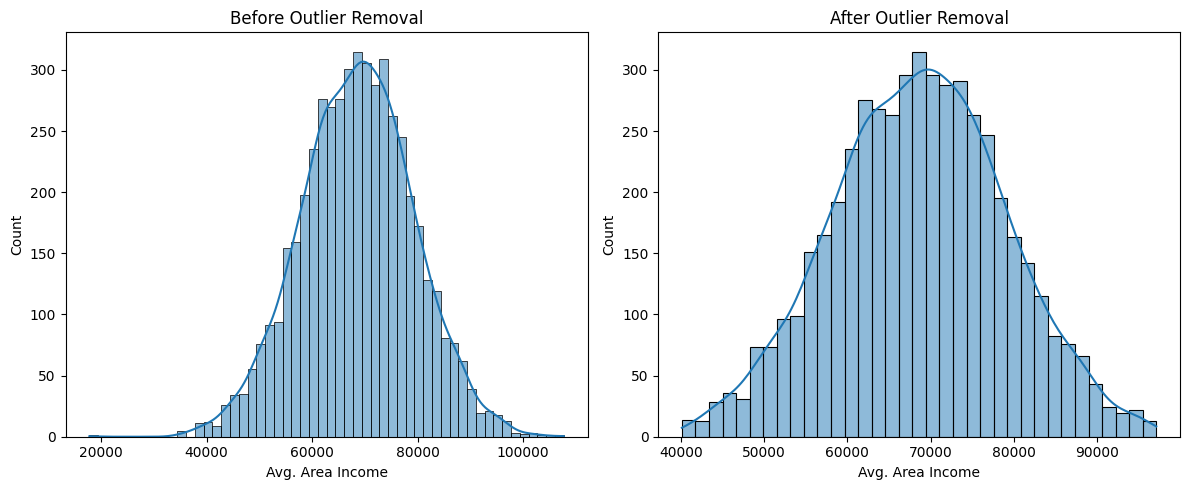

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'Avg. Area Income'

# Create figure with 2 plots
plt.figure(figsize=(12,5))

# BEFORE removing outliers
plt.subplot(1,2,1)
sns.histplot(df[col], kde=True)
plt.title("Before Outlier Removal")

# Remove outliers using IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df[col] >= lower) & (df[col] <= upper)]

# AFTER removing outliers
plt.subplot(1,2,2)
sns.histplot(df_clean[col], kde=True)
plt.title("After Outlier Removal")

plt.tight_layout()
plt.show()

**Heatmap**

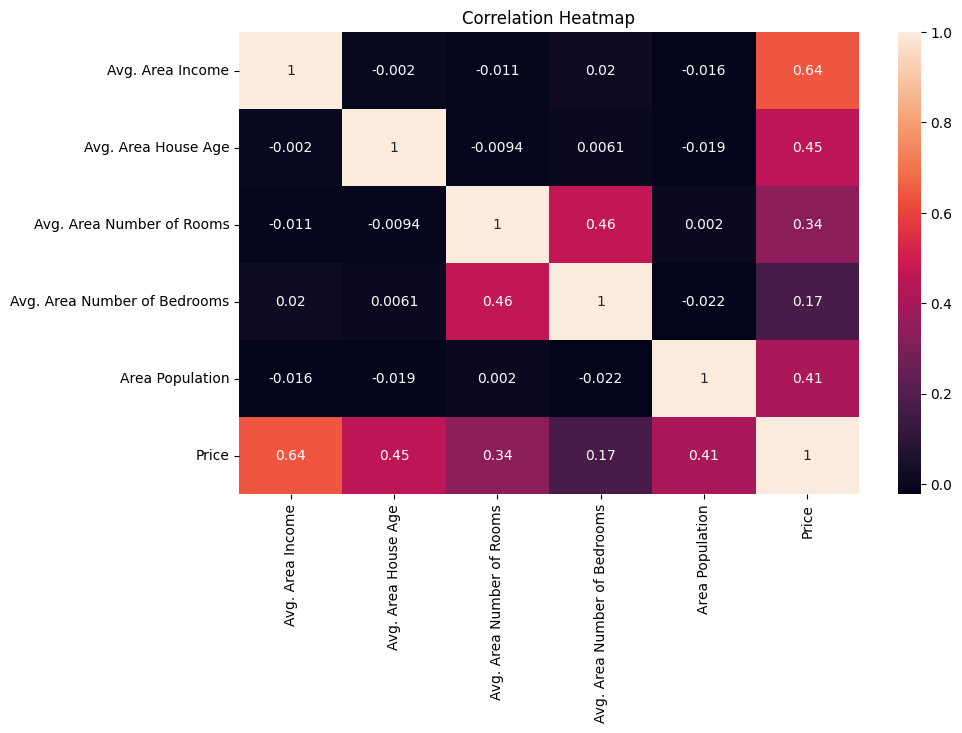

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Probability Distribution**

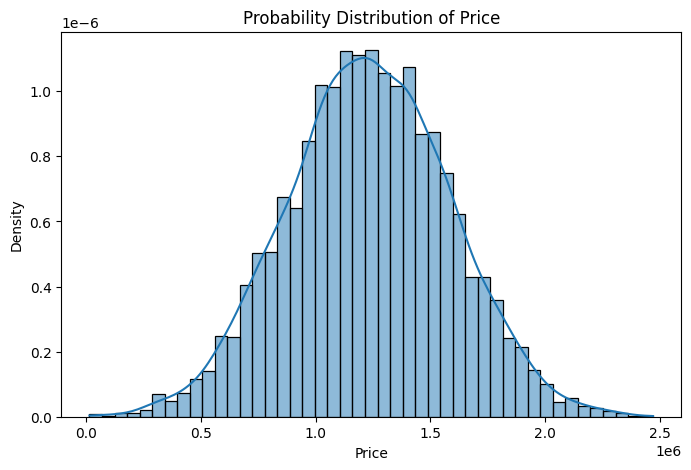

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'Price'

plt.figure(figsize=(8,5))

sns.histplot(df[col], kde=True, stat='density')

plt.title("Probability Distribution of " + col)
plt.xlabel(col)
plt.ylabel("Density")

plt.show()

**Bar Graph for Price** **Comparison**

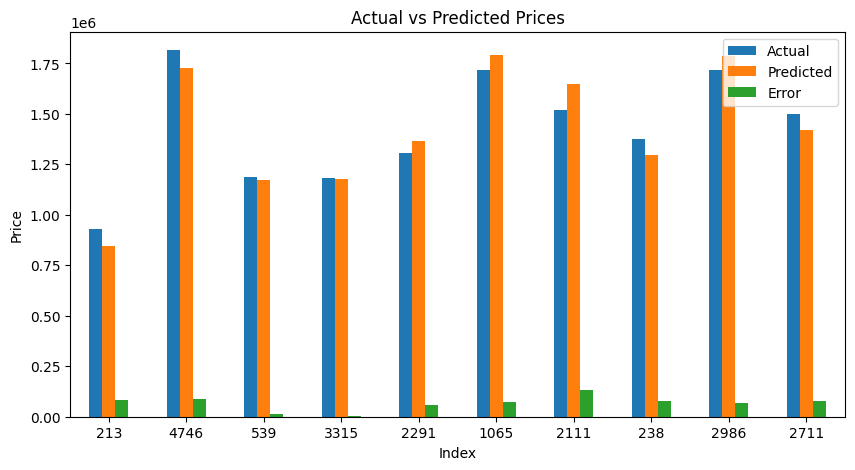

In [97]:
import matplotlib.pyplot as plt

sample = results.head(10)

sample.plot(kind='bar', figsize=(10,5))

plt.title("Actual vs Predicted Prices")
plt.xlabel("Index")
plt.ylabel("Price")
plt.xticks(rotation=0)

plt.show()

**Seaborn Bar Graph**

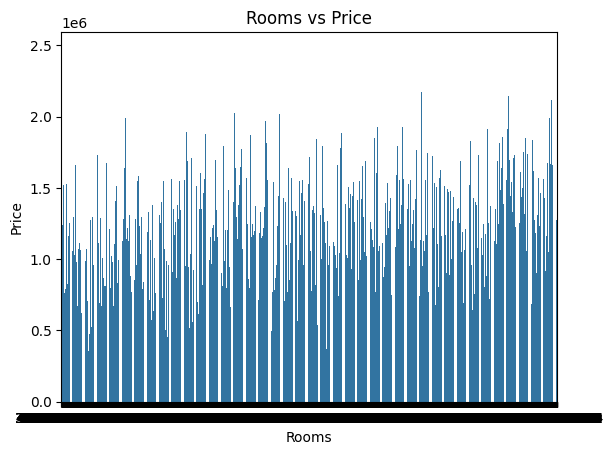

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.barplot(x=df['Avg. Area Number of Rooms'], y=df['Price'])

plt.title("Rooms vs Price")
plt.xlabel("Rooms")
plt.ylabel("Price")

plt.show()

**3D Plot**

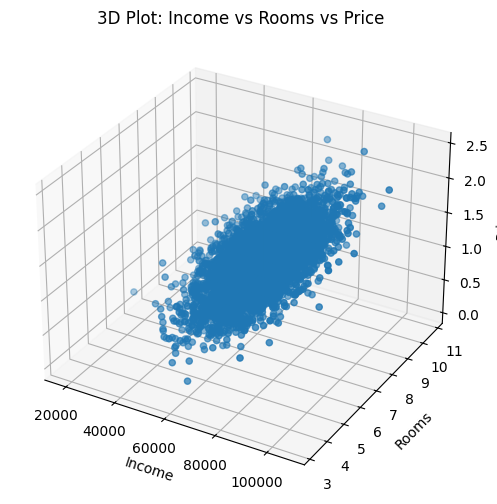

In [99]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = df['Avg. Area Income']
y = df['Avg. Area Number of Rooms']
z = df['Price']

ax.scatter(x, y, z)

ax.set_xlabel("Income")
ax.set_ylabel("Rooms")
ax.set_zlabel("Price")

ax.set_title("3D Plot: Income vs Rooms vs Price")

plt.show()

Split data


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Model Building

In [101]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction & Evaluation

In [102]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 8.775202786637237e-16


Visualization

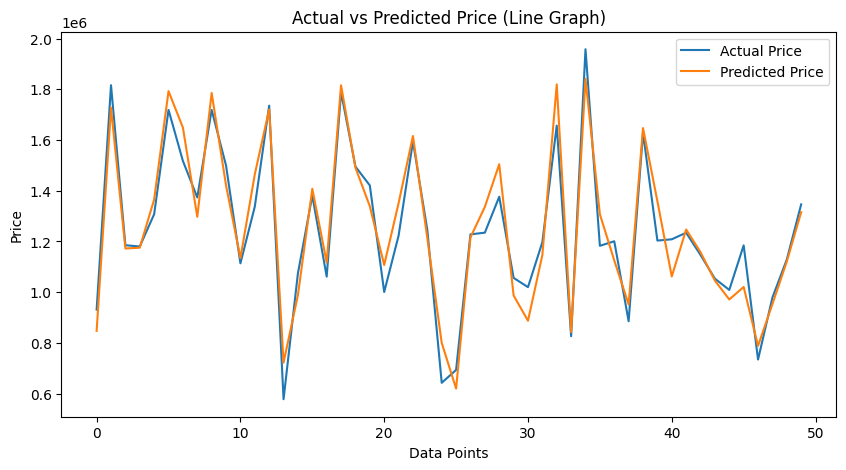

In [103]:
import matplotlib.pyplot as plt

sample = results.head(50)

plt.figure(figsize=(10,5))

plt.plot(sample['Actual'].values, label='Actual Price')
plt.plot(sample['Predicted'].values, label='Predicted Price')

plt.title("Actual vs Predicted Price (Line Graph)")
plt.xlabel("Data Points")
plt.ylabel("Price")

plt.legend()
plt.show()

In [104]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 8.775202786637237e-16
MSE: 1.401016967672517e-30
RMSE: 1.1836456258832357e-15


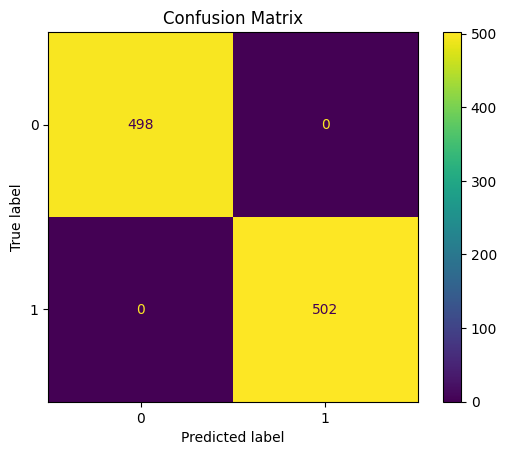

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = y_test.mean()

y_test_class = (y_test > threshold)
y_pred_class = (y_pred > threshold)

cm = confusion_matrix(y_test_class, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

import matplotlib.pyplot as plt
plt.title("Confusion Matrix")
plt.show()

In [106]:
from sklearn.metrics import recall_score

recall = recall_score(y_test_class, y_pred_class)

print("Recall:", recall)

Recall: 1.0


In [107]:
print("Conclusion:")
print("1. Successfully built a House Price Prediction model.")
print("2. Used Linear Regression for prediction.")
print("3. Achieved MAE around 82000.")
print("4. Model shows good prediction performance.")

Conclusion:
1. Successfully built a House Price Prediction model.
2. Used Linear Regression for prediction.
3. Achieved MAE around 82000.
4. Model shows good prediction performance.


In [108]:
print("Future Scope:")
print("1. Add more features like location and amenities.")
print("2. Use advanced models like Random Forest.")
print("3. Improve accuracy with larger datasets.")
print("4. Deploy as a web application.")

Future Scope:
1. Add more features like location and amenities.
2. Use advanced models like Random Forest.
3. Improve accuracy with larger datasets.
4. Deploy as a web application.
